## PyTorch Workflow Fundamentals
The essence of machine learning and deep learning is to take some data from the past, build an algorithm (like a neural network) to discover patterns in it and use the discovered patterns to predict the future.

There are many ways to do this and many new ways are being discovered all the time.

But let's start small.

How about we start with a straight line?

And we see if we can build a PyTorch model that learns the pattern of the straight line and matches it.

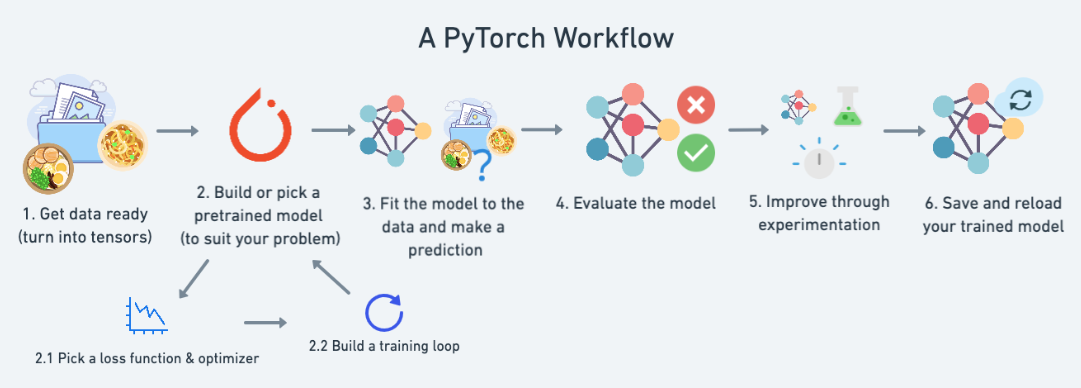


1. Getting data ready	

Data can be almost anything but to get started we're going to create a simple straight line

2. Building a model	

Here we'll create a model to learn patterns in the data, we'll also choose a loss function, optimizer and build a training loop.

3. Fitting the model to data (training)	

We've got data and a model, now let's let the model (try to) find patterns in the (training) data.

4. Making predictions and evaluating a model (inference)	

Our model's found patterns in the data, let's compare its findings to the actual (testing) data.

5. Saving and loading a model	

You may want to use your model elsewhere, or come back to it later, here we'll cover that.

6. Putting it all together	

Let's take all of the above and combine it.

what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}
And now let's import what we'll need for this module.

We're going to get torch, torch.nn (nn stands for neural network and this package contains the building blocks for creating neural networks in PyTorch) and matplotlib.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

INPUT DATA -> CONVERT INTO NUMERICAL REPRESENTATION-> PREDICT OUTPUTS


## Linear Regression

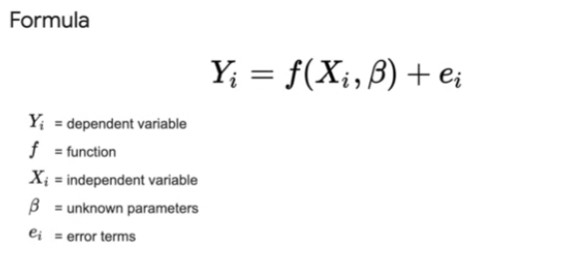

i.e

### Y= a+bX
- b- weight
- a- bias

We'll use linear regression to create the data with known parameters (things that can be learned by a model) and then we'll use PyTorch to see if we can build model to estimate these parameters using gradient descent.

Don't worry if the terms above don't mean much now, we'll see them in action and I'll put extra resources below where you can learn more.

In [2]:
#create known parameters
weight = 0.7
bias = 0.3

#Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(1)
y = weight*X+bias

X[:10], y[:10],len(X),len(y)



(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

### Split data into training and test sets
We've got some data.

But before we build a model we need to split it up.

One of most important steps in a machine learning project is creating a training and test set (and when required, a validation set).

Each split of the dataset serves a specific purpose:

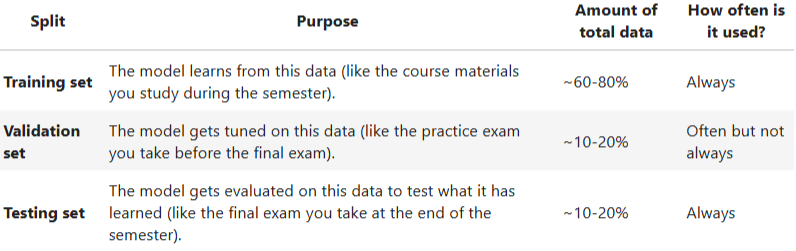

In [3]:
#Create a train.test split
train_split = int(0.8*len(X))
train_split
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)


(40, 40, 10, 10)

### Visualizing data

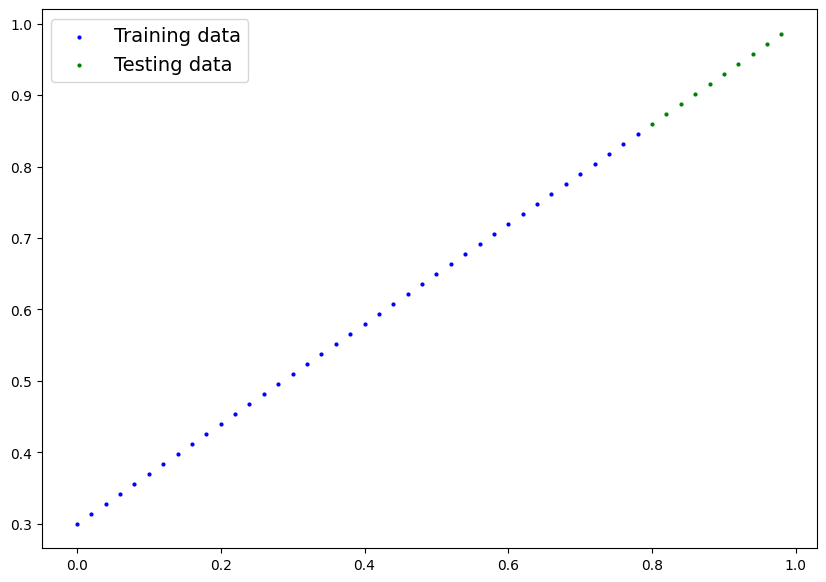

In [4]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10, 7))

    #plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    
    #plot testing data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    #Show legend
    plt.legend(fontsize=14)
plot_predictions()


## Building model

What our model does:- 
- Start with random values(weight &bias)
- Look at training data and adjust the random values to better represent(or get closer to) the ideal values (the weight &bias values we used to create the data)

How does it do so?
Through two main algs:
1. Gradient descent - It is the process of updating the model parameters to minimize the loss function
2. Backpropagation - It is the process of computing the gradients of the loss function with respect to the model parameters

In [5]:
#Create linear regression model
class LinearRegressionModel(nn.Module): #<- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float)) 
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        
        #Forward method to define the computation int he model
    def forward(self, x:torch.Tensor)-> torch.Tensor: #<- 'x" is the input data
        return self.weights * x + self.bias
    
#Alternate way
# class LinearRegressionModelV2(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # Use nn.Linear() for creating the model parameters
#         self.linear_layer = nn.Linear(in_features=1, 
#                                       out_features=1)
    
#     # Define the forward computation (input data x flows through nn.Linear())
#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         return self.linear_layer(x)

# # Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
# torch.manual_seed(42)
# model_1 = LinearRegressionModelV2()
# model_1, model_1.state_dict()

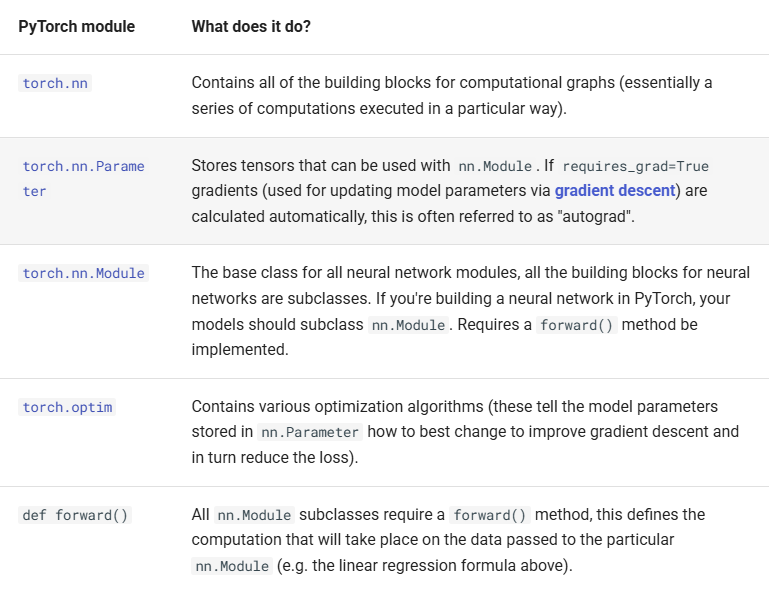

### Checking the contents of our PyTorch model

In [6]:
#Create a random seed
torch.manual_seed(42)

#create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()
list(model_0.parameters())




[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [7]:
model_0.state_dict() #<- returns a dictionary of the model's parameters

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using torch.inference_mode()

Predicting `y_test` based on `X_test` 

The model is gonna run through the `forward()` method

In [8]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

Look how theres grad_fun in normal mode but not in inference mode in the next cell.
This is because we turn off other things(like required_grad= true) so that theres less stuffs running in the bg and with large datasets the predictions get a lot faster

In [9]:
#can also use torch.no_grad() but inference_mode is preferred
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds, y_test


(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

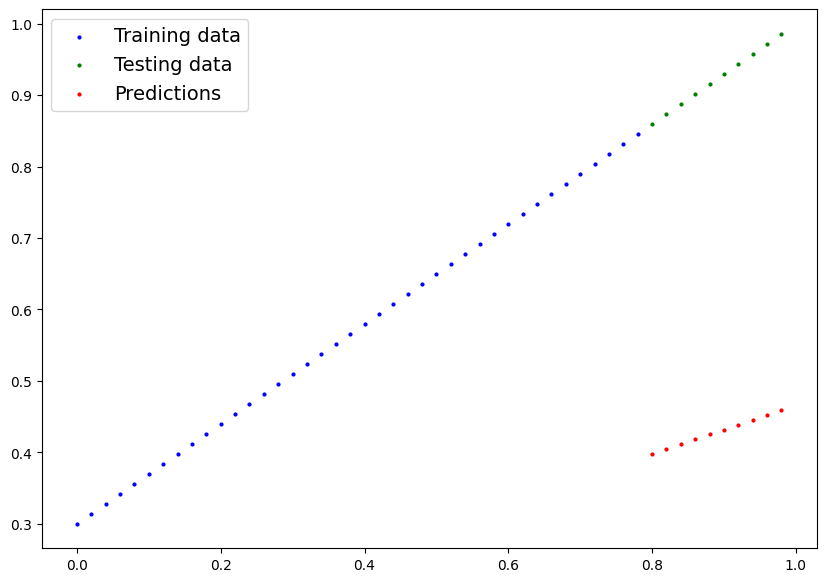

In [10]:
plot_predictions(predictions=y_preds)

### Loss function
- A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.

### Optimizer
- Takes into account the loss of a model and adjusts the model's parameters(e.g.weight&bias in our case) to improve the loss function

In [11]:
#Setup a loss function
loss_fn = nn.L1Loss() #<- L1 loss (mean absolute error)


#Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) #<- stochastic gradient descent with learning rate of 0.01
 

![Screenshot 2025-07-15 225727.png](<attachment:Screenshot 2025-07-15 225727.png>)
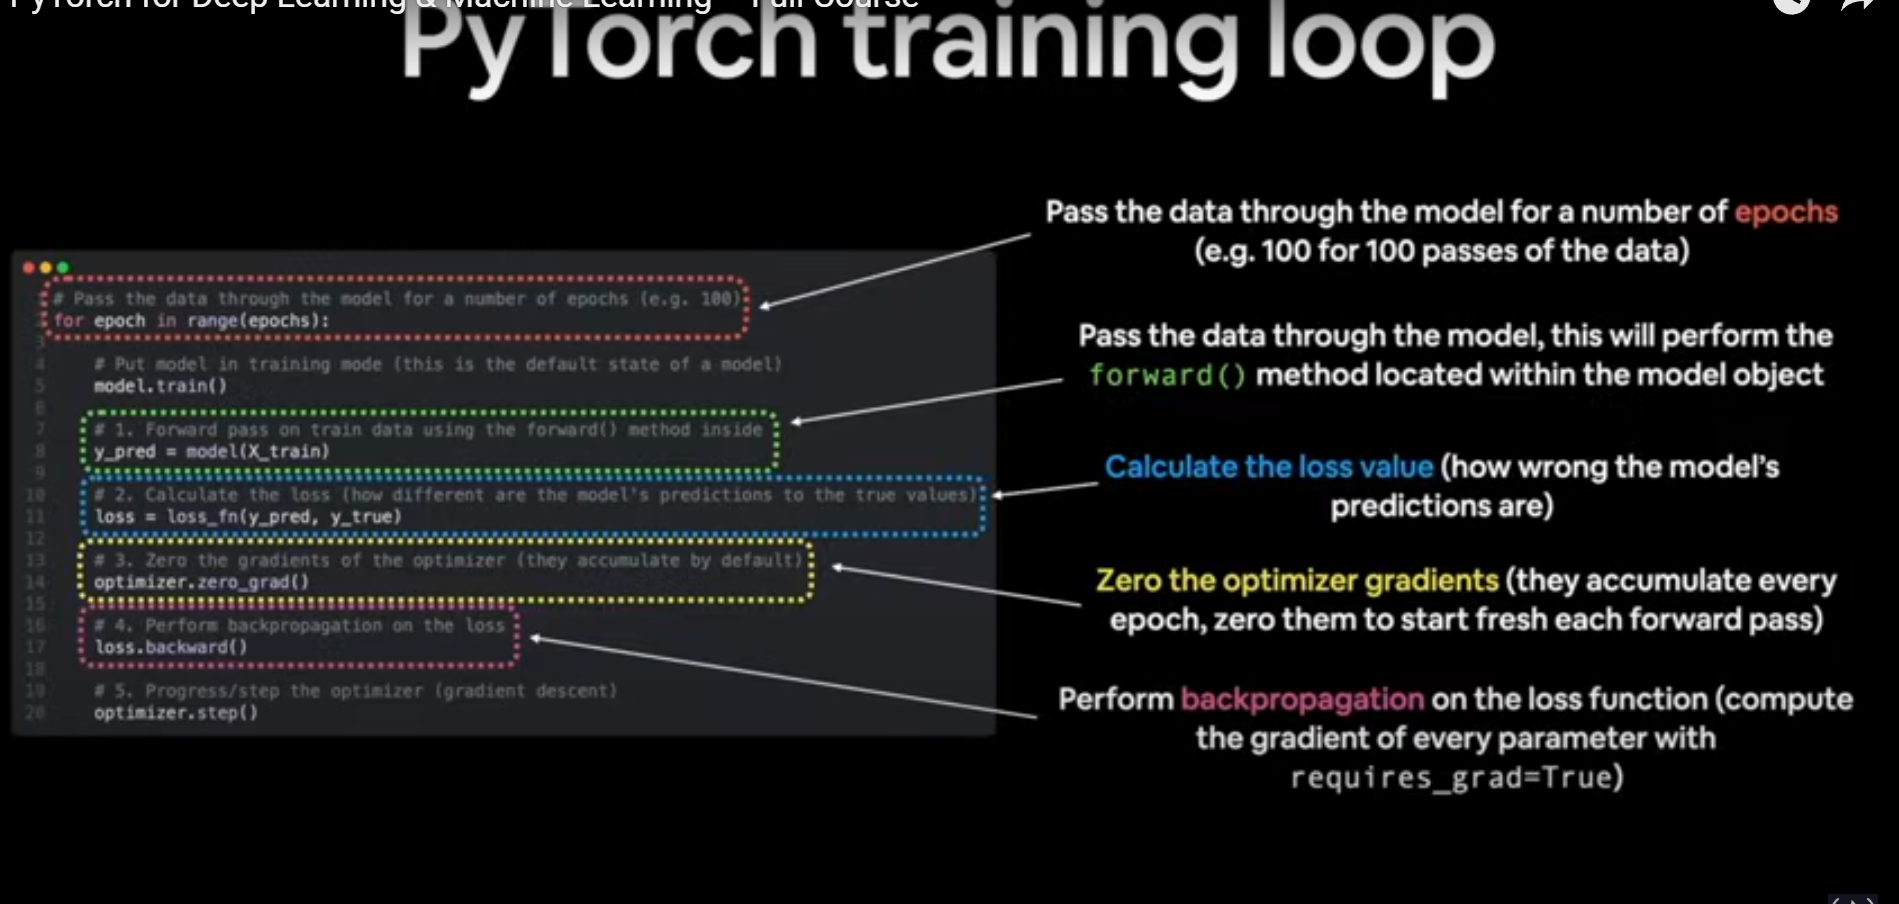

In [12]:
torch.manual_seed(42) #<- set a random seed for reproducibility

#An epoch is one loop through the data....(this is a hyperparameter because we've set it ourselves)
epochs = 200

#Track different values
epoch_count = []
loss_values = []
test_loss_values = []
###Training
#0. Loop through data
for epoch in range(epochs):
    model_0.train() #<- set the model to training mode, it sets all parameters that require gradients to require gradients
    
    #1. Forward pass
    y_pred = model_0(X_train)

    #2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    #3. Optimizer zero grad
    optimizer.zero_grad() #<- clears the gradients of all optimized tensors

    #4. Loss backward
    loss.backward() #<- computes the gradient of the loss with respect to the model parameters

    #5. Optimizer step(perform gradient descent)
    optimizer.step() #<- updates the model parameters based on the gradients computed in the previous step
     

    model_0.eval() #turns off diff settings int he model not needed for evaluation /testing(e.g. dropout, batch normalization)

    with torch.inference_mode(): #turns off gradient tracking(this is preferred over torch.no_grad())
        #1. Do the forward pass
        test_pred = model_0(X_test) 

        #2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")
        print(model_0.state_dict()) #<- prints the model parameters after each epoch


Epoch: 0 | Train Loss: 0.31288 | Test Loss: 0.48107
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Train Loss: 0.19767 | Test Loss: 0.34636
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Train Loss: 0.08909 | Test Loss: 0.21730
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Train Loss: 0.05315 | Test Loss: 0.14464
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Train Loss: 0.04544 | Test Loss: 0.11361
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Train Loss: 0.04168 | Test Loss: 0.09920
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Train Loss: 0.03819 | Test Loss: 0.08887
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Train Loss: 0.03476 | Test Loss: 0.08059
OrderedDict({'weights': tensor([0.5288]), 'bias': tensor([0.3718])})
Epoch: 80 | Train Loss: 0

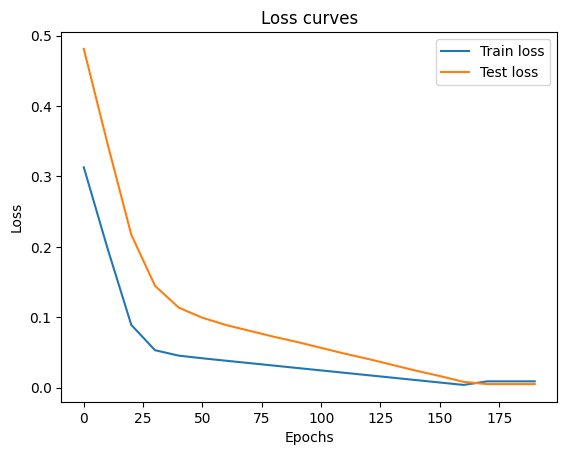

In [13]:
import numpy as np
#Plot the loss curves 
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()) ,label = "Train loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

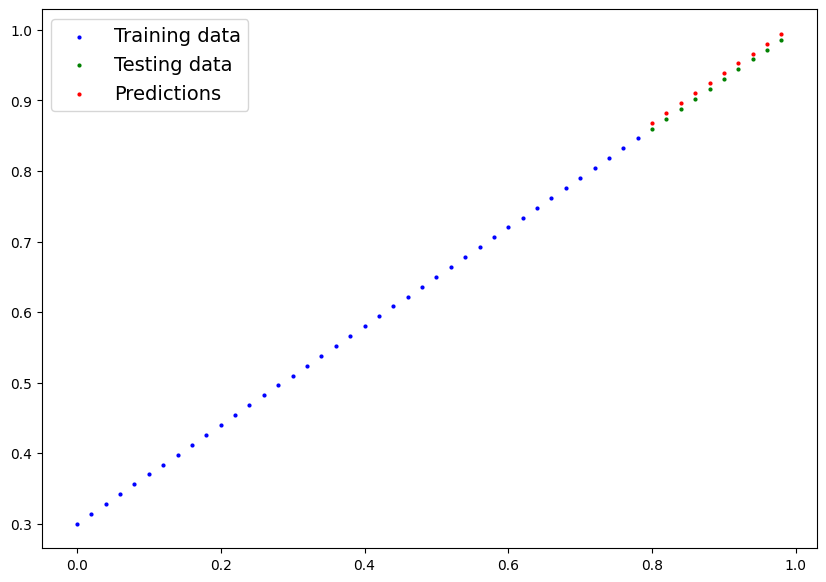

In [14]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)
plot_predictions(predictions=y_preds_new)

### Saving a model in PyTorch

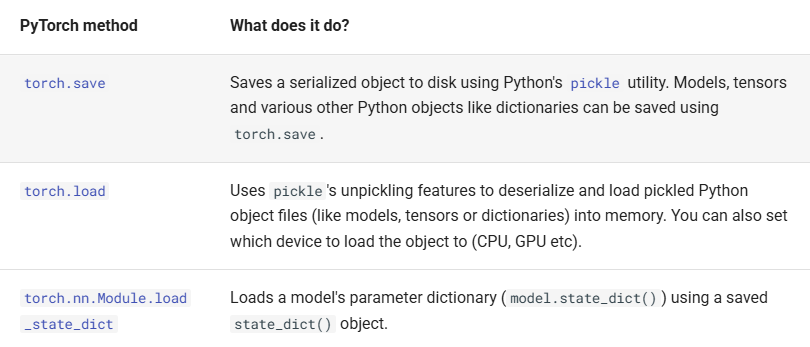

In [15]:
#saving pytorch model
from pathlib import Path

#1. Create a model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) #<- creates the directory if it doesn't exist

#2. create model save path
MODEL_NAME = "1-pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME 

print(f"Saving model to: {MODEL_SAVE_PATH}")

#3. Save the model state dict
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH) 

Saving model to: models\1-pytorch_workflow_model.pth


In [16]:
!dir -l models

 Volume in drive D is New Volume

File Not Found



 Volume Serial Number is EA33-C596

 Directory of d:\Programming\ml_grind\ptorch


 Directory of d:\Programming\ml_grind\ptorch\models

17-07-2025  23:01    <DIR>          .
17-07-2025  23:00    <DIR>          ..
18-07-2025  17:57             1,662 1-pytorch_workflow_model.pth
               1 File(s)          1,662 bytes
               2 Dir(s)  38,687,100,928 bytes free


### Loading the pytorch model

In [17]:
#Loading a model
#1. Create a new instance of the model because we can't load the state dict into a model that doesn't exist
loaded_model_0 = LinearRegressionModel() #It creates a model with random parameters

#2. Load the state dict into the new model instance
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

C:\Users\jayas\AppData\Local\Temp\ipykernel_26848\2221773298.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)

<All keys matched successfully>

In [18]:
loaded_model_0.state_dict() #<- should be the same as the original model's state dict

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [19]:
#Making some predns with our loaded model
loaded_model_0.eval() #<- set the model to evaluation mode
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds==y_preds_new
 

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])